# 2장 1강: 시계열 데이터의 이해와 정상성 진단

## 실습 목표

이번 실습에서는 **Bike Sharing Demand** 데이터를 이용해 시간에 따른 자전거 대여량 변화를 확인합니다.

- 시계열 데이터에서 **시간 순서가 중요한 이유**를 확인합니다.
- 선 그래프와 시계열 분해를 이용해 **Trend / Seasonality / Residual**을 확인합니다.
- 이동평균을 이용해 데이터의 평균적인 수준 변화를 살펴봅니다.
- **ADF Test**를 이용해 정상성을 진단합니다.
- 정상성을 만족하지 않는 경우 **1차 차분**을 적용하고 ADF Test를 다시 수행합니다.

> 이 실습에서는 교안에서 다룬 내용만 사용합니다.

In [ ]:
# 시계열 데이터 : 
# → 1시간 뒤 인구, 2시간 뒤 인구를 알 수 있음

# 관측 간격(Frequency) : 연속한 관측이 어떤 시간 단위로 기록되었는지?
# 시간별, 일별, 주별, 월별

# 시차(lag) : 두 관측 시점 사이에 몇 관측의 간격만큼 떨어져있는지
# lag1은 이전 관측, lag7은 7개 관측 전을 의미 (1시간 간격이면 1시간 전, 7시간 전을 의미)

# 자기상관(Autocorrelation) : 같은 시계열의 값과 일정한 시차만큼 이전 값 사이의 상관관계
# → 여름철 기온이 높은 날에 다음날 같은 시간에도 높은 기온이 이어지는 경향이 있다면 자기상관을 예상할 수 있음
# → 단, 여러 날의 값을 비교해야함 (1~2가지의 케이스만 보고 결정하면 X)

# 추세(Trend) : 시간의 흐름에 따라 장기적인 증가 또는 감소 흐름을 보이는지
# → 주문량이 월별로 100,110,105,120,135 점진적으로 상승하는 추세가 있다.
# → 110에서 105로 떨어지는 구간이 있더라도 그래프를 그려보면 평균적으로 상승하고 있음을 증명

# 계절성(Seasonality) : 일정한 시간 간격을 두고 반복되는 패턴
# → 매주 금요일마다 치킨 배달 수가 늘어난다면 주간 계절성으로 확인할 수 있다.

# 잔차(Residual) : 추세나 계절성 등으로 설명한 뒤 남은 변동
# → 어느 달 매출이 152만원 추세가 130, 계절 성분이 20이라면 잔차는 2, 패턴보다 2만큼 더 관측되었다.
# → 2의 원인은 추가적으로 확인이 필요 

# 이동평균(Moving Average) : 일정한 구간의 평균을 구하고 그 구간을 이동시키면서 반복 계산
# → 단기적인 변동을 완화하여 평균 수준을 보려고 이동 평균을 사용

# 정상성(Stationarity) : 시간이 달라도 시계역의 통상적인 성질이 변하지 않는 성질
# → 101,98,102,99,96,104처럼 100주변에서 비슷하게 오르내리면 정상성에 가깝다라고 표현할 수 있음
# 시계열 모델을 정상적으로 쓸 수 있음

# 비정상 시계열 : 평균, 분산 등의 통계적 특성이 시간에 따라 달라지는 시계열
# → 꾸준하게 회원가입 수가 늘고있는 이커머스 페이지에서 올해 여름에 갑자기 추가로 회원가입 수가 증가했다면
# 기존의 추세와 계절성과 다른 부분이 발생할 수 있다.
# 패턴이 정확하지 않으니 회귀모델을 쓰게될 수도 있음

# 차분(1차) : 현재 값에서 이전 값을 빼 시점 사이의 변화량으로 바꾸는 방법
# → 일별 사용자 수가 10,000 / 10,300 / 10,500 / 10,400명이면 1차 차분의 300, 200, -100

# 차분(2차) : 1차 차분값에 다시 1차 차분을 적용한 값
# → 월별 가입자가 100, 110, 125, 135명이면 
# 1차 차분은 10, 15, 10명
# 2차 차분은 +5, -5다.


## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- statsmodels
- 데이터: `Bike_Sharing_Demand.csv`

### 주요 컬럼

| 컬럼 | 의미 |
|---|---|
| `datetime` | 자전거 대여 기록 시각 |
| `casual` | 비등록 사용자의 대여 수 |
| `registered` | 등록 사용자의 대여 수 |
| `count` | 전체 자전거 대여 수 |

`count`는 `casual + registered`로 구성된 전체 대여량입니다.

## 실습 준비

먼저 데이터를 불러온 뒤 다음 내용을 확인합니다.

1. 데이터 크기와 상위 행
2. 주요 컬럼의 자료형
3. 결측치
4. `datetime`을 날짜/시간 자료형으로 변환
5. 시간 순서대로 정렬
6. 일별·월별 대여량 데이터 준비

> 일별·월별 집계 코드는 이후 시계열 실습을 위한 **준비 코드**로 제공됩니다.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

bike = pd.read_csv("Bike_Sharing_Demand.csv")

print("데이터 크기:", bike.shape)
display(bike.head())

print("\n[자료형]")
display(bike[["datetime", "casual", "registered", "count"]].dtypes.to_frame("dtype"))

print("\n[결측치]")
display(bike[["datetime", "casual", "registered", "count"]].isna().sum().to_frame("missing"))

데이터 크기: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1



[자료형]


,dtype
datetime,str
casual,int64
registered,int64
count,int64



[결측치]


,missing
datetime,0
casual,0
registered,0
count,0


In [3]:
# datetime 변환 및 시간 순서 정렬
bike["datetime"] = pd.to_datetime(bike["datetime"])
bike = bike.sort_values("datetime").reset_index(drop=True)

print("최초 시각:", bike["datetime"].min())

print("마지막 시각:", bike["datetime"].max())
display(bike.head())

최초 시각: 2011-01-01 00:00:00
마지막 시각: 2012-12-19 23:00:00


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
# 일별 시계열 준비
bike["date"] = bike["datetime"].dt.date

daily = (bike.groupby("date", as_index=False)[["count", "casual", "registered"]].sum())

daily["date"] = pd.to_datetime(daily["date"])

# 월별 시계열 준비
bike["month"] = bike["datetime"].dt.to_period("M").astype(str)

monthly = (bike.groupby("month", as_index=False)["count"].sum())

monthly["month"] = pd.to_datetime(monthly["month"])

print("[일별 데이터]")
display(daily.head())

print("\n[월별 데이터]")
display(monthly.head())

[일별 데이터]


,date,count,casual,registered
0,2011-01-01,985,331,654
1,2011-01-02,801,131,670
2,2011-01-03,1349,120,1229
3,2011-01-04,1562,108,1454
4,2011-01-05,1600,82,1518



[월별 데이터]


,month,count
0,2011-01-01,23552
1,2011-02-01,32844
2,2011-03-01,38735
3,2011-04-01,50517
4,2011-05-01,79713


In [15]:
min_date = bike["date"].min()
max_date = bike["date"].max()

all_hour = pd.date_range(start=min_date, end=max_date, freq='D')
missing_hours = all_hour.difference(bike['date'])

print("전체", len(all_hour))
print("누락", len(missing_hours))
print(missing_hours)

전체 719
누락 263
DatetimeIndex(['2011-01-20', '2011-01-21', '2011-01-22', '2011-01-23',
               '2011-01-24', '2011-01-25', '2011-01-26', '2011-01-27',
               '2011-01-28', '2011-01-29',
               ...
               '2012-11-21', '2012-11-22', '2012-11-23', '2012-11-24',
               '2012-11-25', '2012-11-26', '2012-11-27', '2012-11-28',
               '2012-11-29', '2012-11-30'],
              dtype='datetime64[s]', length=263, freq=None)


---

# 필수 1. 시간 흐름과 시계열 패턴 확인

## 배경

시계열 데이터는 값 자체뿐만 아니라 **언제 관측되었는지와 어떤 순서로 나타났는지**가 중요합니다.

Bike Sharing Demand 데이터의 전체 대여량 `count`를 시간 순서대로 확인하고, 월별 대여량을 **Trend / Seasonality / Residual**로 나누어 살펴봅니다.

## 문제 1. 일별 대여량을 시간 순서대로 확인하세요.

### 요구사항

1. `daily["date"]`를 x축, `daily["count"]`를 y축으로 선 그래프를 그립니다.
2. 그래프 제목을 `Daily Bike Rentals`로 설정합니다.
3. 시간의 흐름에 따라 대여량의 전반적인 수준이 어떻게 변화하는지 설명합니다.

### 확인 포인트

- 시계열 그래프에서는 시간 순서를 유지했는가?
- 단순히 개별 값만 보는 것이 아니라 전체적인 흐름을 확인했는가?

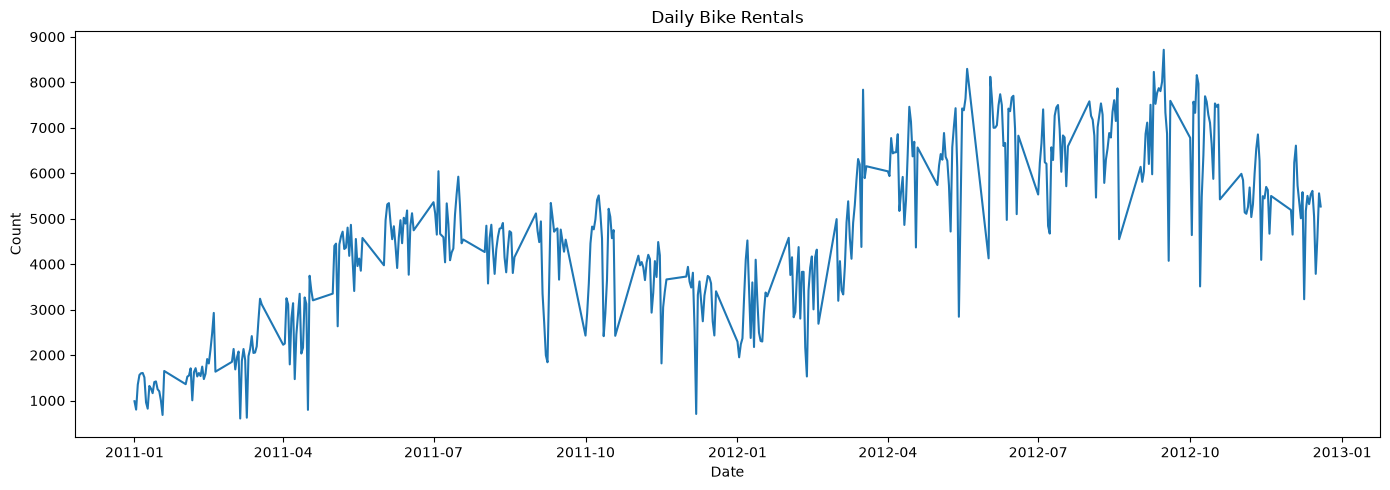

In [5]:
# TODO
# daily["date"]와 daily["count"]를 이용해 선 그래프를 그려보세요.
plt.figure(figsize=(14, 5))
plt.plot(daily["date"], daily["count"])
plt.title("Daily Bike Rentals")
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


`시계열에서 결측과 시간 누락은 다른 개념으로 반드시 시간 누락은 체크해야함`  
수준은 값이 대체로 어느 높이에서 움직이는지, 변동은 그 수준 주변에서 값이 얼마나 오르내리는지  
- 해석 : 관측된 일별 대여량은 2011년보다 2012년에 높은 수준을 보이며, 변동이 상승과 하락이 큰 편이고,  
비교적 여름철에 상승하고 겨울철에 하강하는 모습을 보이지만 시간 누락이 있기 때문에 유의하여 해석해야한다.

### Q1. 왜 `daily` 데이터를 무작위로 섞지 않고 날짜 순서대로 확인해야 할까요?
**답변:**  
- 시계열 데이터에서는 값이 나타난 순서 자체가 정보  
- 날짜 순서가 엉망이면 어떤 값이 언제 발생했고, 나중에 발생했고, 증가나 감소 흐름을 명확하게 파악하기는 어려움


## 문제 2. 월별 대여량을 시계열 분해하세요.

### 요구사항

1. `monthly`의 `month`를 인덱스로 설정합니다.
2. `seasonal_decompose()`를 사용합니다.
3. `model="additive"`를 사용합니다.
4. 월별 데이터의 1년 반복 주기를 확인하기 위해 `period=12`를 사용합니다.
5. 결과에서 `Observed`, `Trend`, `Seasonal`, `Residual`을 확인합니다.

### 확인 포인트

- `period=12`의 의미를 이해했는가?
- Trend / Seasonality / Residual을 구분할 수 있는가?

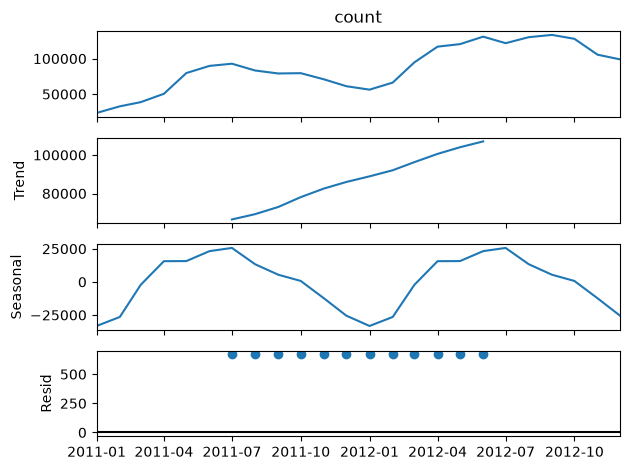

In [16]:
# TODO
# seasonal_decompose()를 이용해 월별 count를 분해해보세요.

monthly_ts = monthly.set_index("month")["count"]
result = seasonal_decompose(monthly_ts, model="additive", period=12)
result.plot()
plt.show()

trend : 여러 달(여기서는 month)에 걸친 장기 수준 변화 (경사 확인)  
-> 우상향(대체로 상승), 경사가 비교적 완만하게 상승중이다.  

seasonal : 12개월 위치에 따라 반복하도록 추정된 편차 (추세보다 강해지거나 약해지는 달이 있는지)  
-> 봄부터 여름까지 상승, 가을 겨울은 하강하는 추세  

Residual : 추세와 계절 성분을 빼고 남은 값 (추세와 계절성으로 설명되지 않은 남은 값 / 잔차)  
-> 잔차의 값이 양수이면 추세와 계절성에 비해 실제 관측값이 큰 편, 음수라면 작은 편  
**주의할 점** : '미래 데이터를 예측한 오차'라는 의미의 잔차라는 뜻은 **아니다.**  

해석 : 월 별 관측 합계를 분해한 결과,  
가운데구간(봄,여름)에서 상승하는 추세와 연말(가을,겨울)에 낮아지는 계절 성분이 나타났고, 추세가 우상향하는 형태로 보여진다.  
잔차는 거의 일정해보이지만 시간 누락과 기간을 고려하여 계산하여야 한다.  


### Q2. 다음 설명을 각각 Trend / Seasonality / Residual과 연결하세요.

**답변:**  
- 시간이 지나면서 나타나는 장기적인 증가 또는 감소  
-> trend  
- 일정한 시간 간격을 두고 반복되는 변화  
-> seasonality  
- 추세와 계절성을 제외하고 남은 변동  
-> residual  

---

# 필수 2. 정상성 진단과 1차 차분

## 배경

정상성은 시간이 지나도 시계열의 **평균적인 수준과 변동의 특성이 크게 달라지지 않는 성질**입니다.

이번 문제에서는 일별 전체 대여량 `count`의 이동평균을 확인하고, ADF Test를 이용해 정상성을 판단합니다. 정상성을 만족한다고 보기 어렵다면 1차 차분을 수행한 뒤 다시 ADF Test를 진행합니다.

## 문제 1. 이동평균으로 평균 수준의 변화를 확인하세요.

### 요구사항

1. `daily["count"]`의 최근 7개 값 이동평균을 계산하여 `rolling_mean` 컬럼에 저장합니다.
2. 원본 `count`와 `rolling_mean`을 같은 그래프에 나타냅니다.
3. 이동평균이 시간에 따라 변하는지 확인합니다.

### 확인 포인트

- `rolling(window=7).mean()`을 사용했는가?
- 이동평균이 개별 값의 작은 변동을 줄여 전체 수준을 보기 위한 방법임을 이해했는가?

,date,count,casual,registered,rolling_mean,count_diff,registered_ma7,registered_diff
0,2011-01-01,985,331,654,NaN,NaN,NaN,NaN
1,2011-01-02,801,131,670,NaN,-184.0,NaN,16.0
2,2011-01-03,1349,120,1229,NaN,548.0,NaN,559.0
3,2011-01-04,1562,108,1454,NaN,213.0,NaN,225.0
4,2011-01-05,1600,82,1518,NaN,38.0,NaN,64.0
5,2011-01-06,1606,88,1518,NaN,6.0,NaN,0.0
6,2011-01-07,1510,148,1362,1344.714286,-96.0,1200.714286,-156.0
7,2011-01-08,959,68,891,1341.000000,-551.0,1234.571429,-471.0
8,2011-01-09,822,54,768,1344.000000,-137.0,1248.571429,-123.0
9,2011-01-10,1321,41,1280,1340.000000,499.0,1255.857143,512.0


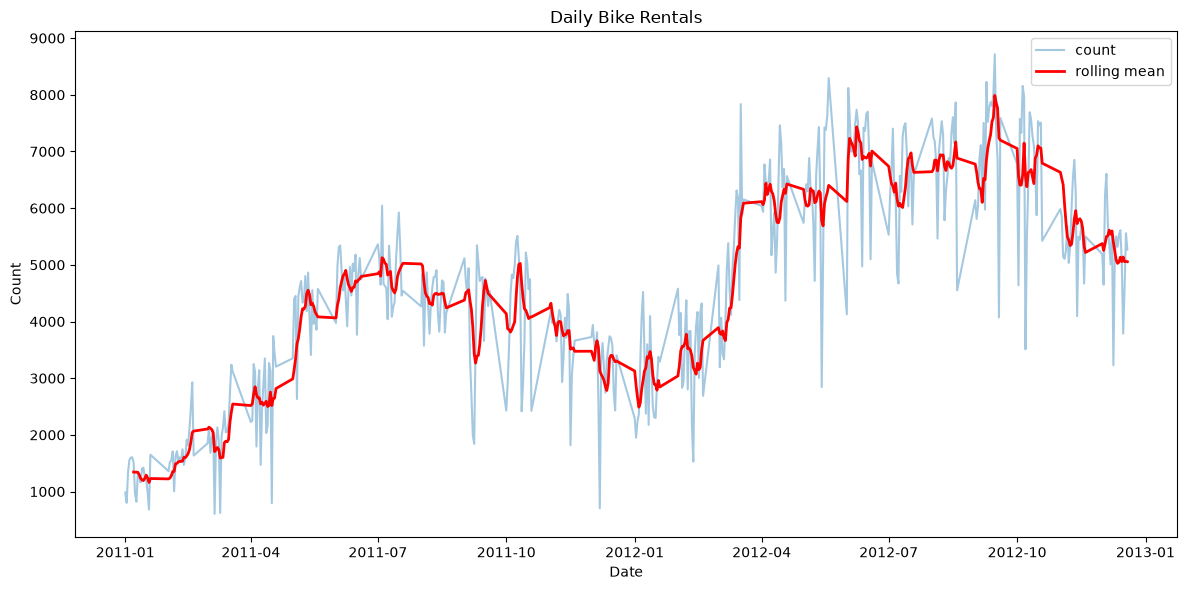

In [ ]:
# TODO
# 7개 값 이동평균을 계산하고 원본 count와 함께 시각화하세요.

# ===== 1. 7일 이동평균 계산 =====
daily["rolling_mean"] = daily["count"].rolling(window=7).mean() # window=7 현재행 기준 최근 7개의 행

display(daily.head(10))

# ===== 2. 원본과 이동평균을 같은 그래프에 =====
plt.figure(figsize=(12, 6))
plt.plot(daily["date"], daily["count"], alpha=0.4, label="count")
plt.plot(daily["date"], daily["rolling_mean"], color="red", linewidth=2, label="rolling mean")
plt.title("Daily Bike Rentals")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

- 이동평균 : 단기 변동을 완화하여 보겠다.  
-> 시계열 보간 방법 중 하나, 여름철 기온  

- 정상성 : 값이 움직이는 중심이 시간에 따라 다르게 나타나는지?  
-> 이동 평균을 통해서 정상성의 가능성을 확인하고자함  

- 7일 평균 : rolling(이동평균) window=7이면 최근 7개의 행을 의미,  
-> 7일을 의미하는 것이 X  

해석 : 최근 7개의 관측값의 평균은 변동폭이 심한 원본데이터의 변동을 완화했지만, 여전히 변동폭의 여파는 남아있다.  
평균 수준이 일정하지 않음을 확인했지 때문에 정상성을 판단하기에는 추가적인 확인이 필요하다.(ADF)

## 문제 2. 원본 일별 대여량에 ADF Test를 수행하세요.

### 요구사항

1. `adfuller()`를 이용해 `daily["count"]`를 검정합니다.
2. ADF Statistic과 p-value를 출력합니다.
3. 유의수준 0.05를 기준으로 정상성을 판단합니다.

### 판단 기준

- `p-value < 0.05` → 귀무가설 기각 → 정상성을 만족한다고 판단
- `p-value ≥ 0.05` → 귀무가설을 기각하지 못함 → 정상성을 만족한다고 보기 어려움

In [8]:
# TODO
# 원본 daily["count"]에 ADF Test를 수행하세요.

result = adfuller(daily["count"])

adf_stat = result[0]
p_value  = result[1]

print(f"ADF Statistic: {adf_stat:.4f}")
print(f"p-value      : {p_value:.4e}")

print("\n임계값(Critical Values):")
for level, value in result[4].items():
    print(f"  {level}: {value:.4f}")

print()
if p_value < 0.05:
    print("→ p-value < 0.05 이므로 귀무가설 기각. 정상성을 만족한다고 판단.")
else:
    print("→ p-value >= 0.05 이므로 귀무가설을 기각하지 못함. 정상성을 만족한다고 보기 어려움.")

ADF Statistic: -2.0025
p-value      : 2.8549e-01

임계값(Critical Values):
  1%: -3.4451
  5%: -2.8680
  10%: -2.5702

→ p-value >= 0.05 이므로 귀무가설을 기각하지 못함. 정상성을 만족한다고 보기 어려움.


C:\Users\sjh96\AppData\Local\Temp\ipykernel_38204\2827445411.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(daily["count"])


귀무가설 : 시계열에 단위근이 존재한다  
대립가설 : 시계열에 단위근이 존재하지 않는다.  
귀무가설 기각 X : 정상성을 만족한다고 보기 어려움  
귀무가설 기각 : 정상성을 만족한다고 볼 수 있음  

ADF 02.00 의미 : 단위근 가설에 대한 증거를 요약한 검정 통계량  
p-value 0.23의미 : 단위근 귀무가설 아래 현재 통계량 또는 기각 방향으로 더 극단적 통계량 확인  

해석 : 원본 전체 대여량의 ADF 통계량: 약 -2, p-value: 약 0.28, 유의수준인 0.05보다 높기 때문에  
-> 단위근 귀무가설을 기각하지 못함  
앞서 이동평균과 함께 1차 차분을 검토해야함. 단 날짜 누락으로 한계점은 뚜렷하게 보임

### Q3. 원본 데이터의 p-value를 기준으로 정상성을 어떻게 판단할 수 있나요?

**답변:**  
-> 귀무가설을 기각하지 못함, 정상성을 만족한다고 보기 어려움

## 문제 3. 1차 차분 후 정상성을 다시 확인하세요.

### 요구사항

1. `.diff()`를 이용해 `daily["count"]`를 1차 차분합니다.
2. 첫 번째 `NaN`은 `dropna()`로 제거합니다.
3. 차분된 값을 선 그래프로 나타냅니다.
4. 차분 데이터에 ADF Test를 다시 수행합니다.
5. 차분 전과 차분 후 p-value를 비교하여 정상성 변화를 설명합니다.

### 확인 포인트

- 차분값이 `현재 값 - 이전 값`이라는 것을 이해했는가?
- 차분 후 데이터의 의미가 **일별 대여량 → 이적 관측일 대비 대여량 변화**로 달라짐을 이해했는가?
- 차분 후 ADF Test를 다시 수행했는가?

차분 전후 비교


,date,count,count_diff
0,2011-01-01,985,NaN
1,2011-01-02,801,-184.0
2,2011-01-03,1349,548.0
3,2011-01-04,1562,213.0
4,2011-01-05,1600,38.0


원본 456행 → 차분 후 455행 (첫 행 NaN 제거)


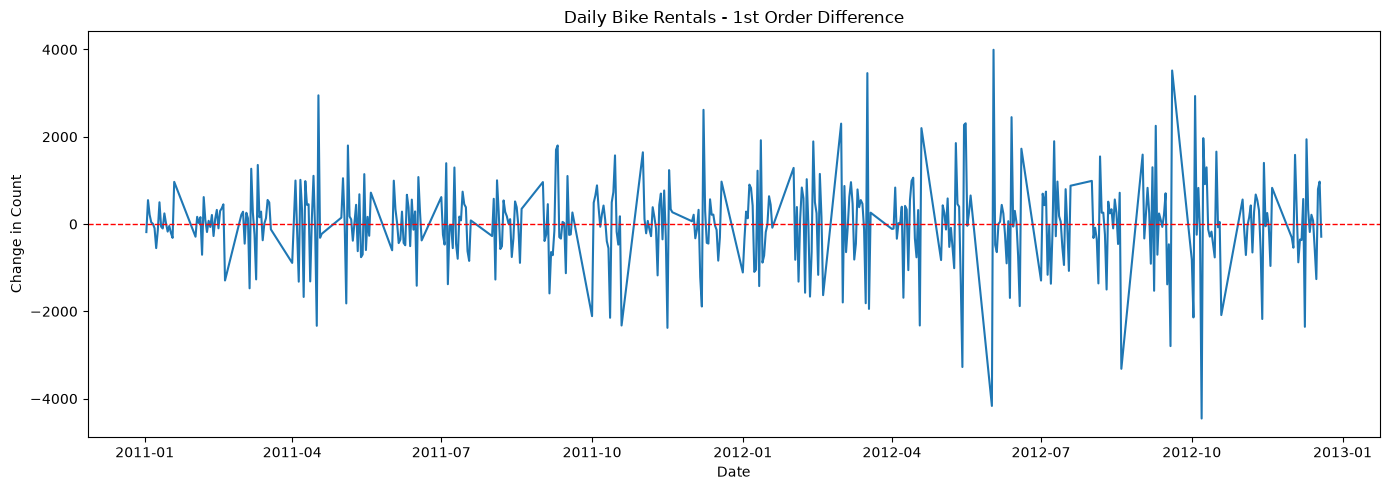

[원본]    ADF=-2.0025, p-value=2.8549e-01
[1차 차분] ADF=-11.7516, p-value=1.2057e-21


C:\Users\sjh96\AppData\Local\Temp\ipykernel_38204\4078519637.py:23: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  res_orig = adfuller(daily["count"])
C:\Users\sjh96\AppData\Local\Temp\ipykernel_38204\4078519637.py:24: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  res_diff = adfuller(diff_data["count_diff"])


In [9]:
# TODO
# 1차 차분 → 시각화 → ADF Test 재실행 순서로 진행하세요.

# ===== 1~2. 1차 차분 후 NaN 제거 =====
daily["count_diff"] = daily["count"].diff()
diff_data = daily.dropna(subset=["count_diff"])

print("차분 전후 비교")
display(daily[["date", "count", "count_diff"]].head())
print(f"원본 {len(daily)}행 → 차분 후 {len(diff_data)}행 (첫 행 NaN 제거)")

# ===== 3. 차분값 선 그래프 =====
plt.figure(figsize=(14, 5))
plt.plot(diff_data["date"], diff_data["count_diff"])
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Daily Bike Rentals - 1st Order Difference")
plt.xlabel("Date")
plt.ylabel("Change in Count")
plt.tight_layout()
plt.show()

# ===== 4. ADF Test 재수행 =====
res_orig = adfuller(daily["count"])
res_diff = adfuller(diff_data["count_diff"])

print(f"[원본]    ADF={res_orig[0]:.4f}, p-value={res_orig[1]:.4e}")
print(f"[1차 차분] ADF={res_diff[0]:.4f}, p-value={res_diff[1]:.4e}")

1차 차분 : t(현재 시간), t-1(관측 행 앞), 관측행의 순서  
2011-01-01 현재 대여량 : 985 이전 대여량 없음 -> 차분값 Nan  
2011-01-02 현재 대여량 : 801 이전 대여량 985 -> 차분값 -184  
-> 이전 관측일보다 184건 감소했다. (전날 대비 X, 시계열은 관측일로 얘기하기)  

original 그래프와 차분 그래프 차이  
원본 그래프 : 대여량 수준이 1000~9000건 사이에서 크게 움직임  
차분 그래프 : 대여량 수준이 비교적 0에서 대체로 움직임  
-> 차분은 그래프의 변동폭이 일정한가?를 직관적으로 보기위해 진행  

차분 전 후 검정 판단 비교  
원본 : p-value(0.28) -> 0.05보다 크기때문에 귀무가설을 기각하지 못함 (정상성을 만족한다고 보기 어려움)  
1차 차분 : p-value(1.2e-21) -> 0.05보다 작기때문에 귀무가설을 기각 (정상성을 만족한다고 볼 수 있음)  

해석 : 원본 시계열에서 p-value는 0.28로 귀무가설을 기각하지 못했으나, 1차 차분 후에는 1.2e-21로 귀무가설을 기각함.  
차분 그래프에는 변화의 폭이 줄고 0 주변의 값이 나타남  
-> 단 여전하게도 큰 변동폭들이 남아있고, 누락 날짜가 있기 때문에 추가적으로 변동폭 확인이 필요

### Q4. 차분 전과 차분 후 데이터의 의미는 어떻게 달라지나요?

**답변:**  
차분 전 count : 각 관측일에 기록된 전체 자전거 대여량 합계  
차분 후 count_diff : 이전 관측일 대비 전체 자전거 대여량 합계의 증감

---

# 과제 1. 등록 사용자 대여량의 정상성 진단

## 배경

필수 2에서는 전체 대여량 `count`를 이용해 정상성 진단과 차분을 수행했습니다.

이번에는 같은 과정을 **등록 사용자 대여량 `registered`**에 직접 적용합니다.

> 과제는 필수 실습에서 연습한 방법을 동일하게 적용하는 수준입니다.

## 요구사항

1. `daily["registered"]`를 날짜 순서대로 선 그래프로 나타냅니다.
2. 최근 7개 값의 이동평균을 계산하여 원본 데이터와 함께 나타냅니다.
3. 원본 `registered`에 ADF Test를 수행합니다.
4. p-value를 기준으로 정상성을 판단합니다.
5. 정상성을 만족한다고 보기 어렵다면 1차 차분합니다.
6. 1차 차분을 수행한 경우, 차분 데이터에 ADF Test를 다시 수행합니다.
7. 원본과 차분 데이터의 p-value를 근거로 정상성 판단을 설명합니다. 차분하지 않았다면 그 이유를 설명합니다.
8. 진단 결과를 근거로 원본 데이터를 사용할지, 1차 차분한 데이터를 사용할지, 추가 진단이 필요한지 선택하고 이유를 설명합니다.

### 확인 포인트

- 원본 데이터의 시간 흐름을 확인했는가?
- 이동평균으로 평균 수준의 변화를 확인했는가?
- ADF Test의 p-value를 0.05와 비교했는가?
- 필요한 경우 1차 차분 후 ADF Test를 다시 수행했는가?
- 결과를 코드 출력값을 근거로 설명했는가?
- ADF 검정 결과와 그래프를 근거로 이후 모델링 방향을 선택했는가?


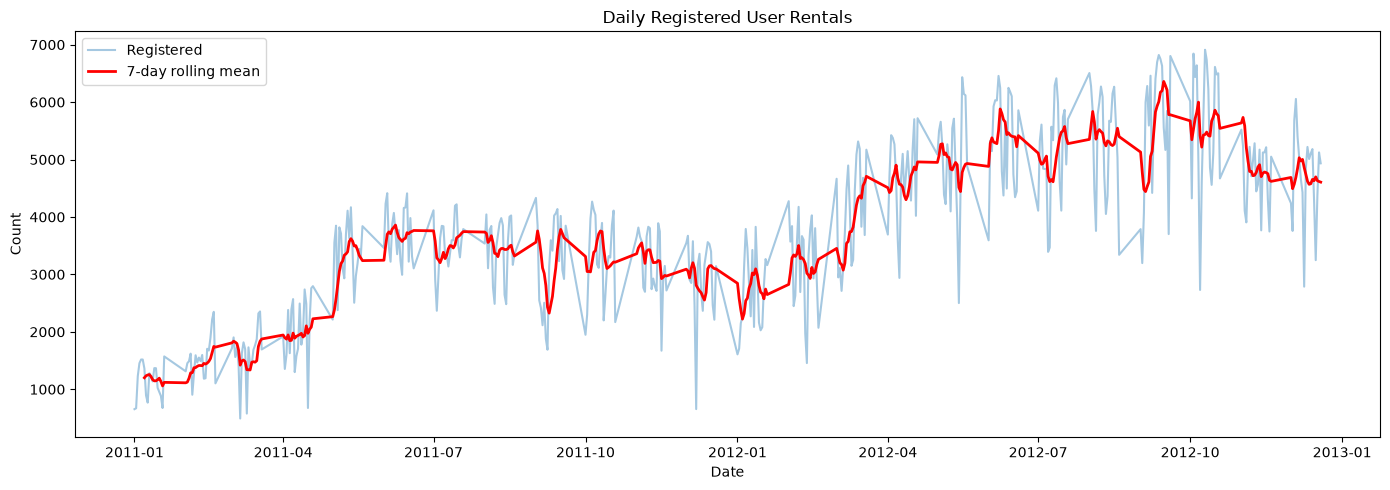

[원본 registered]  ADF Statistic = -1.9070
                   p-value       = 3.2879e-01
  → 정상성을 만족한다고 보기 어려움


C:\Users\sjh96\AppData\Local\Temp\ipykernel_38204\25218610.py:20: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  res_orig = adfuller(daily["registered"])


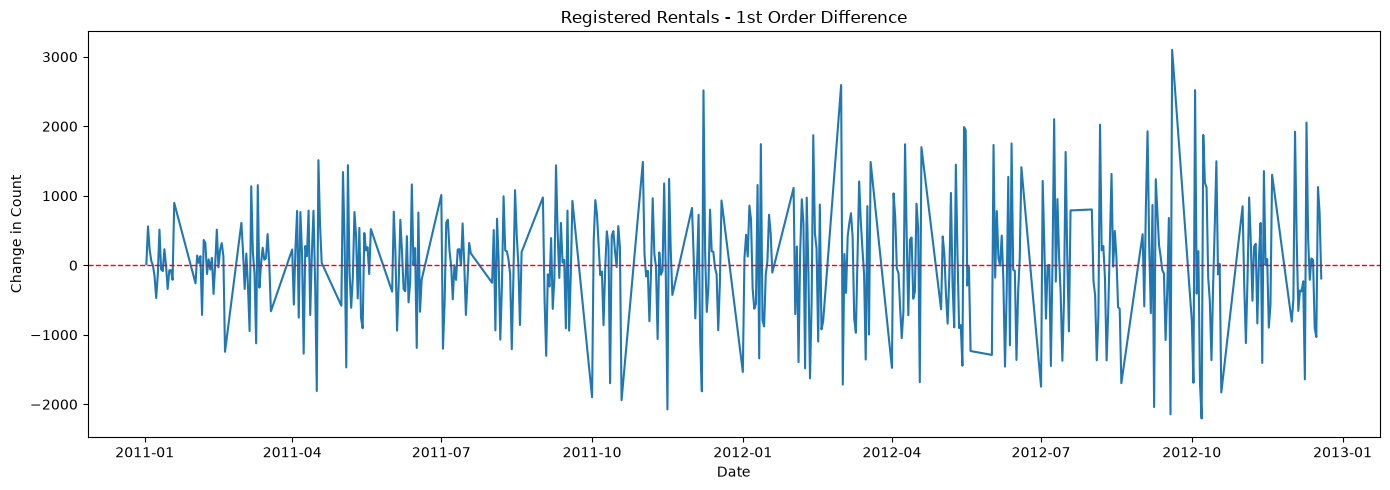

[1차 차분]         ADF Statistic = -6.3537
                   p-value       = 2.5739e-08
  → 정상성 만족

원본 평균 수준: 앞 1/3 2,541 / 뒤 1/3 5,187
차분 평균 수준: 앞 1/3 24.2 / 뒤 1/3 -5.2


C:\Users\sjh96\AppData\Local\Temp\ipykernel_38204\25218610.py:39: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  res_diff = adfuller(diff_reg["registered_diff"])


In [10]:
# TODO
# 시각화 → 최근 7개 값 이동평균 → 원본 ADF Test
# → 필요 시 1차 차분 및 ADF Test 재실행 → 결과 비교
# Q5·Q6에는 출력값과 그래프를 근거로 해석과 모델링 방향을 작성하세요.

# ===== 1~2. 원본 + 7일 이동평균 시각화 =====
daily["registered_ma7"] = daily["registered"].rolling(window=7).mean()

plt.figure(figsize=(14, 5))
plt.plot(daily["date"], daily["registered"], alpha=0.4, label="Registered")
plt.plot(daily["date"], daily["registered_ma7"], color="red", linewidth=2, label="7-day rolling mean")
plt.title("Daily Registered User Rentals")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# ===== 3~4. 원본 ADF Test =====
res_orig = adfuller(daily["registered"])
print(f"[원본 registered]  ADF Statistic = {res_orig[0]:.4f}")
print(f"                   p-value       = {res_orig[1]:.4e}")
print("  →", "정상성 만족" if res_orig[1] < 0.05 else "정상성을 만족한다고 보기 어려움")

# ===== 5. 1차 차분 =====
daily["registered_diff"] = daily["registered"].diff()
diff_reg = daily.dropna(subset=["registered_diff"])

plt.figure(figsize=(14, 5))
plt.plot(diff_reg["date"], diff_reg["registered_diff"])
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Registered Rentals - 1st Order Difference")
plt.xlabel("Date")
plt.ylabel("Change in Count")
plt.tight_layout()
plt.show()

# ===== 6. 차분 데이터 ADF Test =====
res_diff = adfuller(diff_reg["registered_diff"])
print(f"[1차 차분]         ADF Statistic = {res_diff[0]:.4f}")
print(f"                   p-value       = {res_diff[1]:.4e}")
print("  →", "정상성 만족" if res_diff[1] < 0.05 else "정상성을 만족한다고 보기 어려움")

# ===== 해석에 쓸 보조 근거 =====
third = len(daily) // 3
print(f"\n원본 평균 수준: 앞 1/3 {daily['registered'].head(third).mean():,.0f} / 뒤 1/3 {daily['registered'].tail(third).mean():,.0f}")
print(f"차분 평균 수준: 앞 1/3 {diff_reg['registered_diff'].head(third).mean():.1f} / 뒤 1/3 {diff_reg['registered_diff'].tail(third).mean():.1f}")


### Q5. 원본 등록 사용자 대여량의 ADF 검정 결과를 어떻게 해석할 수 있나요?  
### 차분했다면 차분 전후 결과를 비교하고, 차분하지 않았다면 그 이유를 설명하세요.

**답변:**
원본 registered 의 ADF Test 결과 p-value 는 3.2879e-01로,    
유의수준 0.05 보다 크기 때문에 귀무가설(단위근이 존재)을 기각하지 못함.  
-> 원본 데이터는 정상성을 만족한다고 보기 어려움.  

그래프에서도 7일 이동평균선이 수평이 아닌 2011년 1월 약 1,200건에서 2012년 9월 약 6,000건까지 우상향 함.  
구간별 평균을 비교하면 앞 1/3 이 2,541건, 뒤 1/3 이 5,187건으로 약 2.04배 상승함.  
-> 정상성의 조건인 "평균이 시간에 따라 일정하다"를 만족한다고 보기 어려움

이에 `1차 차분한 뒤` ADF Test 를 재실행한 결과 p-value 는 2.5739e-08 로,  
유의수준 0.05 보다 작아 귀무가설을 기각.  
-> 1차 차분 데이터는 정상성을 만족한다고 볼 수 있음.

차분 데이터의 구간별 평균도 앞 1/3 이 24.2, 뒤 1/3 이 -5.2로 나타남.  
원본은 두 구간의 차이가 2,646 이었으나 차분 후에는 29.4 로, 일일 대여량 수천 건 규모에 비해 0 에 가깝다고 볼 수 있음.  

### Q6. 이후 시계열 모델링에서는 원본 데이터 사용, 1차 차분 데이터 사용, 추가 진단 중 어떤 방향을 선택하겠나요? ADF 검정 결과와 그래프를 근거로 설명하세요.

**답변:**

- 1차 차분한 데이터를 사용함.

ADF 검정 결과, 원본은 p-value 3.2879e-01 로 유의수준 0.05 보다 크기 때문에 귀무가설을 기각하지 못해 정상성을 만족한다고 보기 어려웠으나,  
`1차 차분 후에는` p-value 2.5739e-08 로 유의수준 0.05보다 작기 때문에 귀무가설이 기각되어 `정상성을 만족한다고 볼 수 있음.`  
ADF Statistic 도 -1.9070 에서 -6.3537 로 낮아짐. 1차 차분만으로 정상성을 만족한다고 볼 수 있기 때문에 1차 차분 데이터를 사용.

그래프에서도 원본은 7일 이동평균선이 2011년 1월 약 1,200건에서 2012년 9월 약 6,000건까지 우상향하여 평균 수준이 계속 변했으며,  
구간별 평균도 앞 1/3 2,541건에서 뒤 1/3 5,187건으로 약 2.04배 상승함.  

차분 그래프에서는 이 우상향이 사라지고 값이 양수와 음수를 반복함.  
구간별 평균도 앞 1/3 24.2 에서 뒤 1/3 -5.2 로, 두 구간의 차이가 원본 2,646 에서 29.4 로 줄어 평균 수준의 이동이 사라짐.  
-> 1차 차분 데이터를 사용하며, ARIMA 적용 시 1차 차분 횟수를 나타내는 d = 1 로 설정함.


---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 시계열 데이터에서 시간 순서가 중요한 이유는 무엇인가요?
2. Trend와 Seasonality의 차이는 무엇인가요?
3. ADF Test에서 `p-value ≥ 0.05`라면 어떻게 해석하나요?
4. 1차 차분은 어떤 값을 계산하나요?
5. 차분 후 ADF Test를 다시 수행해야 하는 이유는 무엇인가요?